<a href="https://colab.research.google.com/github/brucenguyen0302-code/last-mile-route-duration/blob/main/notebooks/AT1_II_route_duration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Last-Mile Delivery Route Duration

Delivery routes are planned by software, but drivers often change the planned stop order, so the time a route
really takes can differ a lot from the plan. This notebook builds regression models that predict the **actual
duration of a delivery route (in minutes)** using only information that is known before the route starts.

**Data:** Konovalenko, A., Hvattum, L. M., & Iversen, K. A. H. (2024). *Last-mile delivery route deviations
dataset: Planned vs. actual routes* [Data set]. Mendeley Data. https://doi.org/10.17632/kkwgfvmtxn.1

## 1. Setup

Mount Google Drive, fix one random seed so every run gives the same results, and create the project folders
for data, results and figures.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import os, glob, random, sys
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE = '/content/gdrive/MyDrive/IntroToAI/AT1_II'
DATA_DIR = os.path.join(BASE, 'data')
RESULTS_DIR = os.path.join(BASE, 'results')
FIG_DIR = os.path.join(BASE, 'figures')
for folder in (DATA_DIR, RESULTS_DIR, FIG_DIR):
    os.makedirs(folder, exist_ok=True)

print('Python :', sys.version.split()[0])
print('pandas :', pd.__version__)
print('numpy  :', np.__version__)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Python : 3.13.15
pandas : 2.2.3
numpy  : 2.1.3


## 2. Load the dataset

The data file is `routes_performance.xlsx`. The notebook searches Google Drive for it by name instead of using a
fixed path. Reading a 20 MB Excel file is slow, so the first run saves a fast copy (a pickle file) in the data
folder and later runs load that copy instead.

In [2]:
DATA_FILE = 'routes_performance.xlsx'
CACHE_FILE = os.path.join(DATA_DIR, 'routes_performance_raw.pkl')

if os.path.exists(CACHE_FILE):
    raw = pd.read_pickle(CACHE_FILE)
    print('Loaded from cache:', CACHE_FILE)
else:
    matches = glob.glob(f'/content/gdrive/MyDrive/**/{DATA_FILE}', recursive=True)
    assert matches, f'{DATA_FILE} not found anywhere in Google Drive'
    DATA_PATH = matches[0]
    print('Reading:', DATA_PATH)
    raw = pd.read_excel(DATA_PATH, sheet_name=0)
    raw.to_pickle(CACHE_FILE)
    print('Saved cache:', CACHE_FILE)

print(f'Rows    : {len(raw):,}')
print(f'Columns : {raw.shape[1]}')

Loaded from cache: /content/gdrive/MyDrive/IntroToAI/AT1_II/data/routes_performance_raw.pkl
Rows    : 249,231
Columns : 16


## 3. First look at the data

Each row is one visit to a stop on a route. This cell shows the first rows, counts missing values, and lists
each column's type, number of unique values and range.

In [3]:
display(raw.head(10))

print('Missing values in the whole table:', int(raw.isna().sum().sum()))

summary = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'unique values': raw.nunique(),
    'min': raw.min(numeric_only=True),
    'max': raw.max(numeric_only=True),
}).reindex(raw.columns)
pd.set_option('display.float_format', '{:,.2f}'.format)
display(summary)

,Route ID,Driver ID,Stop ID,Address ID,Week ID,Country,Day of Week,IndexP,IndexA,Arrived Time,Earliest Time,Latest Time,DistanceP,DistanceA,Depot,Delivery
0,0,0,0,0,0,1,Monday,0,0,42.275,0.0,360.0,0.000000,0.000000,1,0
1,0,0,1,1,0,1,Tuesday,1,4,332.788,240.0,480.0,16.329053,16.329053,0,1
2,0,0,2,2,0,1,Tuesday,2,5,332.956,120.0,540.0,0.373110,0.373110,0,1
3,0,0,3,3,0,1,Monday,3,2,244.994,60.0,540.0,2.491915,0.000000,0,1
4,0,0,4,3,0,1,Monday,4,1,244.855,60.0,540.0,0.000000,13.944962,0,1
5,0,0,0,0,0,1,Monday,5,3,272.121,0.0,360.0,13.944962,13.944962,1,0
6,0,0,1,1,0,1,Tuesday,6,6,373.553,240.0,480.0,16.329053,0.373110,0,1
7,1,1,0,0,0,1,Monday,0,0,64.855,0.0,360.0,0.000000,0.000000,1,0
8,1,1,5,4,0,1,Monday,1,2,75.520,120.0,540.0,16.767937,11.916344,0,1
9,1,1,6,5,0,1,Tuesday,2,5,324.371,120.0,540.0,0.080666,0.725253,0,1


Missing values in the whole table: 0


,dtype,unique values,min,max
Route ID,int64,19647,0.00,"19,646.00"
Driver ID,int64,400,0.00,399.00
Stop ID,int64,13125,0.00,"13,124.00"
Address ID,int64,10864,0.00,"10,863.00"
Week ID,int64,32,0.00,31.00
Country,int64,2,0.00,1.00
Day of Week,object,7,NaN,NaN
IndexP,int64,36,0.00,35.00
IndexA,int64,36,0.00,35.00
Arrived Time,float64,197396,0.00,"12,814,321.85"


## 4. Check the dataset against its description

The file is compared with the dataset summary published by its authors (Konovalenko et al., 2026, Table 1).

In [4]:
n_routes = raw['Route ID'].nunique()
n_drivers = raw['Driver ID'].nunique()
n_locations = raw['Address ID'].nunique()
n_weeks = raw['Week ID'].nunique()
rows_per_route = raw.groupby('Route ID').size()

paper_table = pd.DataFrame({
    'Konovalenko et al. (2026), Table 1': [19647, 400, 10864, 13, 3, 36],
    'This file': [n_routes, n_drivers, n_locations, round(rows_per_route.mean()),
                  rows_per_route.min(), rows_per_route.max()],
}, index=['Routes', 'Drivers', 'Unique locations', 'Average stops per route',
          'Minimum stops per route', 'Maximum stops per route'])
paper_table['Match'] = paper_table.iloc[:, 0] == paper_table.iloc[:, 1]
display(paper_table)

print(f"Weeks     : {n_weeks} (Week ID {raw['Week ID'].min()} to {raw['Week ID'].max()})")
print(f"Countries : {sorted(raw['Country'].unique().tolist())}")

assert paper_table['Match'].all()
assert raw.shape == (249231, 16) and n_weeks == 32
assert raw.isna().sum().sum() == 0
assert raw['Route ID'].is_monotonic_increasing, 'Routes are expected in date order'
print('\nAll checks passed.')

,"Konovalenko et al. (2026), Table 1",This file,Match
Routes,19647,19647,True
Drivers,400,400,True
Unique locations,10864,10864,True
Average stops per route,13,13,True
Minimum stops per route,3,3,True
Maximum stops per route,36,36,True


Weeks     : 32 (Week ID 0 to 31)
Countries : [0, 1]

All checks passed.


## 5. Build one row per route

The raw table has one row per stop visit, but the prediction is made for a whole route, so the stop rows are
grouped into one row per route.

**Target.** The route duration is the time between the first and the last recorded arrival in the route:

$$\text{duration\_min} = \max(\text{Arrived Time}) - \min(\text{Arrived Time})$$

**Features.** To avoid data leakage, the features only use information that the planner already has before the
driver leaves the depot: the planned stop sequence (`IndexP`), the planned leg distances (`DistanceP`), the
customer time windows, the stop types, the country, the weekday and the driver's history. The columns that record
what actually happened (`IndexA`, `DistanceA`, `Arrived Time`) are only used to build the target and the
data-quality flags, never as model inputs.

| Feature | Meaning |
|---|---|
| `n_stops` | Number of customer stop visits |
| `n_depot_visits` | Number of times the plan passes through the depot |
| `n_pickups` | Number of pickup stops |
| `n_addresses` | Number of different customer addresses |
| `planned_km` | Total planned driving distance |
| `max_leg_km` | Longest single planned leg |
| `first_leg_km` | Planned distance from the depot to the first customer |
| `earliest_start` | Earliest opening time of any customer time window |
| `latest_end` | Latest closing time of any customer time window |
| `mean_window` | Average customer time-window width |
| `min_window` | Narrowest customer time window |
| `country` | Country of operation (0 or 1) |
| `weekday` | Day of the week of the first planned stop |
| `driver_prior_routes` | Number of routes the driver completed in earlier rows of the data |

Two quality flags are also created for the cleaning step: whether the arrival times increase along the actual
driving order, and whether the actual route starts at the depot.

In [5]:
stops = raw.copy()
stops['is_stop'] = (stops['Depot'] == 0).astype(int)
stops['is_pickup'] = ((stops['Depot'] == 0) & (stops['Delivery'] == 0)).astype(int)
stops['window_width'] = stops['Latest Time'] - stops['Earliest Time']

planned = stops.sort_values(['Route ID', 'IndexP'])
actual = stops.sort_values(['Route ID', 'IndexA'])
by_plan = planned.groupby('Route ID')
by_actual = actual.groupby('Route ID')
by_customer = planned[planned['is_stop'] == 1].groupby('Route ID')

routes = pd.DataFrame({
    'week_id': by_plan['Week ID'].first(),
    'driver_id': by_plan['Driver ID'].first(),
    'country': by_plan['Country'].first(),
    'weekday': by_plan['Day of Week'].first(),
    'n_stops': by_plan['is_stop'].sum(),
    'n_depot_visits': by_plan['Depot'].sum(),
    'n_pickups': by_plan['is_pickup'].sum(),
    'n_addresses': by_customer['Address ID'].nunique(),
    'planned_km': by_plan['DistanceP'].sum(),
    'max_leg_km': by_plan['DistanceP'].max(),
    'first_leg_km': by_customer['DistanceP'].first(),
    'earliest_start': by_customer['Earliest Time'].min(),
    'latest_end': by_customer['Latest Time'].max(),
    'mean_window': by_customer['window_width'].mean(),
    'min_window': by_customer['window_width'].min(),
    'duration_min': by_actual['Arrived Time'].max() - by_actual['Arrived Time'].min(),
    'flag_in_order': by_actual['Arrived Time'].apply(lambda t: t.is_monotonic_increasing),
    'flag_depot_first': by_actual['Depot'].first() == 1,
}).reset_index()

routes['driver_prior_routes'] = routes.groupby('driver_id').cumcount()

print(f'Stop rows : {len(stops):,}')
print(f'Routes    : {len(routes):,}')
print(f'Columns   : {routes.shape[1]}')
display(routes.head())

Stop rows : 249,231
Routes    : 19,647
Columns   : 20


,Route ID,week_id,driver_id,country,weekday,n_stops,n_depot_visits,n_pickups,n_addresses,planned_km,max_leg_km,first_leg_km,earliest_start,latest_end,mean_window,min_window,duration_min,flag_in_order,flag_depot_first,driver_prior_routes
0,0,0,0,1,Monday,5,2,0,3.00,49.47,16.33,16.33,60.00,540.00,372.00,240.00,331.28,True,True,0
1,1,0,1,1,Monday,6,1,0,6.00,33.27,16.77,16.77,120.00,540.00,360.00,180.00,306.53,True,True,0
2,2,0,2,1,Monday,6,1,0,6.00,12.12,8.22,8.22,120.00,600.00,320.00,180.00,362.99,True,True,0
3,3,0,3,1,Monday,9,1,0,8.00,19.04,14.69,14.69,120.00,600.00,306.67,120.00,254.09,True,True,0
4,4,0,4,1,Monday,7,1,0,7.00,20.63,10.36,10.36,240.00,780.00,334.29,240.00,160.75,True,True,0


### Check the route table

The assertions confirm that no stop row was lost or double-counted when the rows were grouped, and that the
routes are still in date order. The summary of the target and the flags shows how much of the data has quality
problems before any cleaning.

In [6]:
assert routes['Route ID'].is_unique
assert len(routes) == raw['Route ID'].nunique()
assert (routes['n_stops'] + routes['n_depot_visits']).sum() == len(raw)
assert routes['Route ID'].is_monotonic_increasing and routes['week_id'].is_monotonic_increasing

print('Route duration (minutes), before cleaning:')
display(routes['duration_min'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)

print(f"Arrival times in driving order : {routes['flag_in_order'].mean():.1%}")
print(f"Actual route starts at depot   : {routes['flag_depot_first'].mean():.1%}")
print(f"Routes with no customer stops  : {(routes['n_stops'] == 0).sum()}")
print(f"Routes with zero duration      : {(routes['duration_min'] == 0).sum()}")
print(f"Routes longer than 24 hours    : {(routes['duration_min'] > 1440).sum()}")

Route duration (minutes), before cleaning:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_min,"19,647.00",451.77,"1,351.41",0.00,0.00,5.76,267.28,354.16,444.05,624.80,"2,787.85","57,552.85"


Arrival times in driving order : 92.3%
Actual route starts at depot   : 94.7%
Routes with no customer stops  : 30
Routes with zero duration      : 738
Routes longer than 24 hours    : 390


## 6. Clean the route table

Section 5.1 showed that some routes contain recording errors: arrival times out of order, routes that do not
start at the depot, durations of zero and durations of several days. These routes do not describe a real delivery
shift, so they are removed. Each rule is based on a physical or legal limit rather than on how unusual a value
looks, so genuine long or short routes are kept.

| Rule | A route is kept only if… | Reason |
|---|---|---|
| R1 | it has at least one customer stop | A route that only visits the depot is not a delivery route. |
| R2 | its arrival times increase along the actual driving order | A driver cannot arrive at a later stop before an earlier one, so the timestamps are corrupted. |
| R3 | its actual driving order starts at the depot | The duration is measured from the depot departure; without it the start time is unknown. |
| R4 | all customer time windows open and close within one day (0–1,440 minutes) | A same-day delivery window cannot close days later; values such as 12.8 million minutes are recording errors. |
| R5 | its duration is at most 780 minutes (13 hours) | Workers in Norway and Denmark must have at least 11 consecutive hours of rest in every 24 hours (Directive 2003/88/EC), so one shift cannot span more than 13 hours. |
| R6 | its implied average speed (planned km ÷ duration) is at most 130 km/h | 130 km/h is the highest legal speed limit in either country, so a faster route is physically impossible. |
| R7 | it takes at least one minute per customer stop | Handing over or collecting a parcel takes time, so a shorter route cannot have been driven. |

The rules are applied in order, and the log records how many routes each rule removes. The same rules are applied
to every week of data before the split, because they describe whether a record is valid, not how the model is
trained.

In [7]:
speed_kmh = routes['planned_km'] / (routes['duration_min'] / 60)

rules = {
    'R1 has customer stops': routes['n_stops'] > 0,
    'R2 arrivals in driving order': routes['flag_in_order'],
    'R3 starts at the depot': routes['flag_depot_first'],
    'R4 time windows within one day': (routes['earliest_start'] <= 1440) & (routes['latest_end'] <= 1440),
    'R5 duration at most 13 hours': routes['duration_min'] <= 780,
    'R6 average speed at most 130 km/h': (routes['duration_min'] > 0) & (speed_kmh <= 130),
    'R7 at least 1 minute per stop': routes['duration_min'] >= routes['n_stops'],
}

keep = pd.Series(True, index=routes.index)
log = []
for name, passed in rules.items():
    passed = passed.fillna(False).astype(bool)
    removed = int((keep & ~passed).sum())
    keep &= passed
    log.append({'rule': name, 'failed (any order)': int((~passed).sum()),
                'removed at this step': removed, 'routes left': int(keep.sum())})

cleaning_log = pd.DataFrame(log)
cleaning_log.to_csv(os.path.join(RESULTS_DIR, 'cleaning_log.csv'), index=False)
display(cleaning_log)

routes_clean = routes.loc[keep].drop(columns=['flag_in_order', 'flag_depot_first']).reset_index(drop=True)
print(f'Routes kept    : {len(routes_clean):,} of {len(routes):,} ({len(routes_clean) / len(routes):.1%})')
print(f'Routes removed : {len(routes) - len(routes_clean):,}')

,rule,failed (any order),removed at this step,routes left
0,R1 has customer stops,30,30,19617
1,R2 arrivals in driving order,1513,1509,18108
2,R3 starts at the depot,1045,1020,17088
3,R4 time windows within one day,351,217,16871
4,R5 duration at most 13 hours,604,416,16455
5,R6 average speed at most 130 km/h,1002,405,16050
6,R7 at least 1 minute per stop,959,2,16048


Routes kept    : 16,048 of 19,647 (81.7%)
Routes removed : 3,599


### Check the cleaned table

The assertions confirm that every rule holds in the cleaned table, that no values are missing, and that every
week still has enough routes for a chronological split. The summary shows the target after cleaning.

In [8]:
assert routes_clean.isna().sum().sum() == 0
assert routes_clean['duration_min'].between(1, 780).all()
assert (routes_clean['duration_min'] >= routes_clean['n_stops']).all()
assert routes_clean['latest_end'].le(1440).all() and routes_clean['earliest_start'].le(1440).all()
assert routes_clean['Route ID'].is_monotonic_increasing

print('Route duration (minutes), after cleaning:')
display(routes_clean['duration_min'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame().T)

per_week = routes_clean.groupby('week_id').size()
print(f'Routes per week: min {per_week.min()}, median {per_week.median():.0f}, max {per_week.max()}')
assert per_week.min() >= 300

routes_clean.to_pickle(os.path.join(DATA_DIR, 'routes_clean.pkl'))
print('Saved:', os.path.join(DATA_DIR, 'routes_clean.pkl'))

Route duration (minutes), after cleaning:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
duration_min,"16,048.00",358.26,120.11,2.16,94.70,167.62,277.04,352.98,434.49,568.16,664.82,776.73


Routes per week: min 350, median 491, max 617
Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/data/routes_clean.pkl


## 7. Explore the route table

This section looks at the cleaned routes before any modelling: how the target is distributed, which planned
features move with it, whether the two countries and the weekdays behave differently, and whether route
durations drift over the 32 weeks. The last point matters because the models will be trained on earlier weeks and
tested on later ones.

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#1f1f1f', '#6b6b6b', '#e6e6e6'

plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'left',
    'axes.labelcolor': INK,
    'axes.edgecolor': GRID,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'legend.frameon': False,
})

def save_figure(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    plt.show()
    print('Saved:', path)

FEATURES_NUM = ['n_stops', 'n_depot_visits', 'n_pickups', 'n_addresses', 'planned_km', 'max_leg_km',
                'first_leg_km', 'earliest_start', 'latest_end', 'mean_window', 'min_window',
                'driver_prior_routes']
FEATURES_CAT = ['country', 'weekday']
TARGET = 'duration_min'
print(f'{len(FEATURES_NUM)} numeric and {len(FEATURES_CAT)} categorical features')

12 numeric and 2 categorical features


### 7.1 Distribution of route duration

A histogram of the target shows its typical value and spread, and whether it is skewed enough to need a
transformation before modelling.

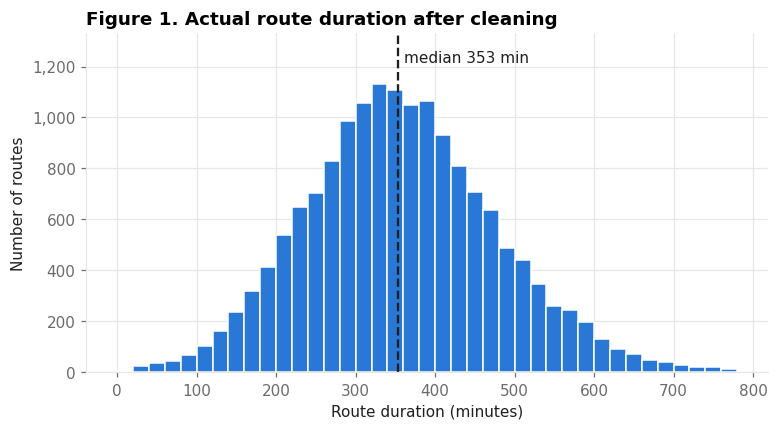

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig01_duration_distribution.png
Skewness : 0.24
Median   : 353.0 min (5.9 h)
IQR      : 277.0 to 434.5 min


In [10]:
y_all = routes_clean[TARGET]
median_all = y_all.median()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_all, bins=np.arange(0, 800, 20), color=BLUE, edgecolor='white', linewidth=1)
ax.axvline(median_all, color=INK, linewidth=1.5, linestyle='--')
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.text(median_all + 8, ax.get_ylim()[1] * 0.95, f'median {median_all:.0f} min', color=INK, va='top')
ax.set_title('Figure 1. Actual route duration after cleaning')
ax.set_xlabel('Route duration (minutes)')
ax.set_ylabel('Number of routes')
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
save_figure(fig, 'fig01_duration_distribution.png')

print(f'Skewness : {y_all.skew():.2f}')
print(f'Median   : {median_all:.1f} min ({median_all / 60:.1f} h)')
print(f'IQR      : {y_all.quantile(.25):.1f} to {y_all.quantile(.75):.1f} min')

### 7.2 Which planned features move with duration?

Spearman's rank correlation measures how consistently duration rises or falls with each numeric feature, without
assuming a straight-line relationship. It is used here only to describe the data; the models themselves decide
how to use each feature.

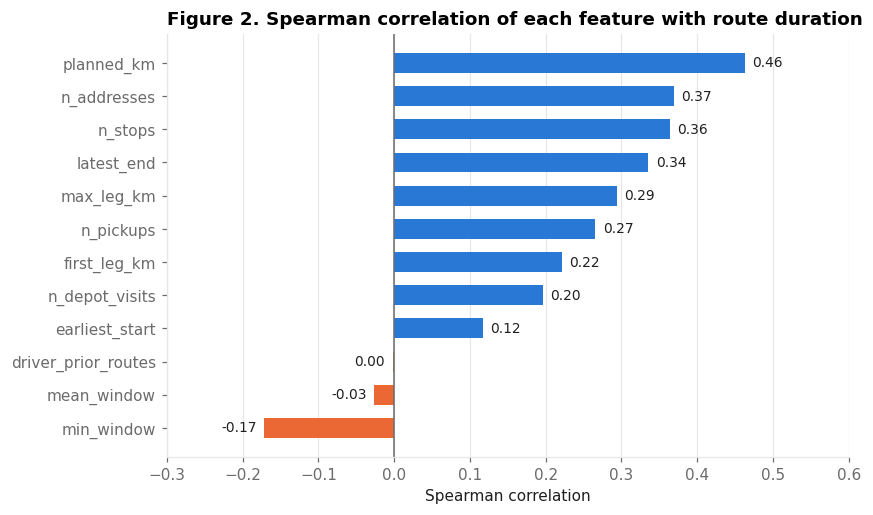

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig02_feature_correlation.png


,spearman
planned_km,0.46
n_addresses,0.37
n_stops,0.36
latest_end,0.34
max_leg_km,0.29
n_pickups,0.27
first_leg_km,0.22
n_depot_visits,0.20
earliest_start,0.12
driver_prior_routes,-0.00


In [11]:
spearman = (routes_clean[FEATURES_NUM + [TARGET]]
            .corr(method='spearman')[TARGET]
            .drop(TARGET)
            .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = [BLUE if v >= 0 else ORANGE for v in spearman]
ax.barh(spearman.index, spearman.values, color=colors, height=0.6)
ax.axvline(0, color=MUTED, linewidth=1)
for i, v in enumerate(spearman.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{round(v, 2) + 0.0:.2f}', va='center',
            ha='left' if v >= 0 else 'right', color=INK, fontsize=9)
ax.set_xlim(-0.3, 0.6)
ax.grid(axis='y', visible=False)
ax.set_title('Figure 2. Spearman correlation of each feature with route duration')
ax.set_xlabel('Spearman correlation')
save_figure(fig, 'fig02_feature_correlation.png')

display(spearman.sort_values(ascending=False).round(3).to_frame('spearman'))

### 7.3 Duration against planned distance and number of stops

The two strongest features are plotted against duration. With about 16,000 routes, individual points would
overlap, so each panel shows how many routes fall in each cell (darker = more routes), with the median duration of each
band drawn on top.

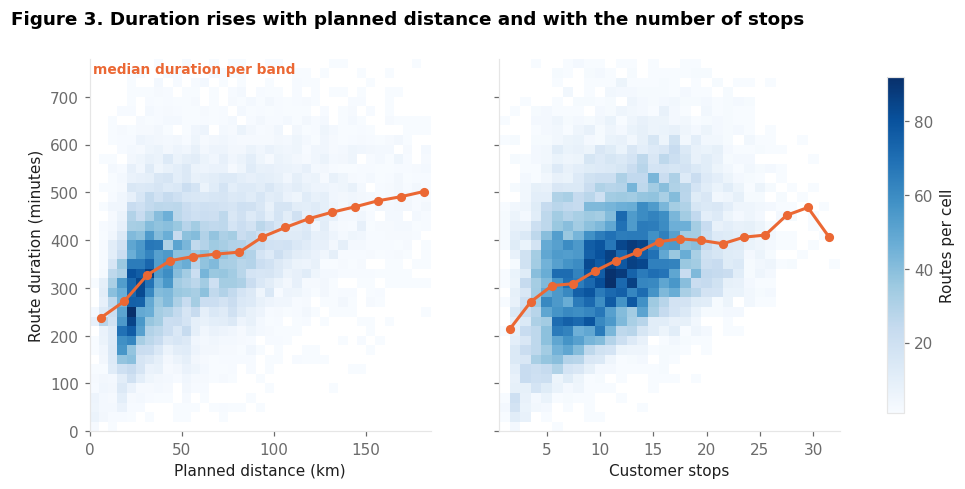

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig03_duration_vs_distance_stops.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)

km_cap = routes_clean['planned_km'].quantile(0.99)
y_bins = np.arange(0, 800, 20)
panels = [
    (axes[0], 'planned_km', 'Planned distance (km)', np.arange(0, km_cap + 5, 5), np.arange(0, km_cap + 10, 12.5)),
    (axes[1], 'n_stops', 'Customer stops', np.arange(0.5, 33.5, 1), np.arange(0.5, 33.5, 2)),
]
for ax, col, label, x_bins, band_edges in panels:
    data = routes_clean[routes_clean[col] <= x_bins[-1]]
    counts, _, _, image = ax.hist2d(data[col], data[TARGET], bins=[x_bins, y_bins], cmap='Blues', cmin=1)
    band_median = data.groupby(pd.cut(data[col], band_edges), observed=True)[TARGET].median()
    centres = [interval.mid for interval in band_median.index]
    ax.plot(centres, band_median.values, color=ORANGE, linewidth=2, marker='o', markersize=5)
    ax.set_xlabel(label)
    ax.grid(False)

axes[0].text(2, 750, 'median duration per band', color=ORANGE, fontsize=9, fontweight='bold')
axes[0].set_ylabel('Route duration (minutes)')
fig.suptitle('Figure 3. Duration rises with planned distance and with the number of stops',
             x=0.06, ha='left', fontweight='bold', fontsize=12)
fig.colorbar(image, ax=axes, label='Routes per cell', shrink=0.9)
save_figure(fig, 'fig03_duration_vs_distance_stops.png')

### 7.4 Differences between countries and weekdays

The two categorical features are summarised as tables of route counts and median durations.

In [13]:
by_country = routes_clean.groupby('country')[TARGET].agg(routes='size', median='median', mean='mean', std='std')
display(by_country.round(1))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_weekday = (routes_clean.groupby('weekday')[TARGET]
              .agg(routes='size', median='median', mean='mean', std='std')
              .reindex(weekday_order))
display(by_weekday.round(1))

,routes,median,mean,std
country,,,,
0,6312,386.00,390.30,116.30
1,9736,331.00,337.50,118.00


,routes,median,mean,std
weekday,,,,
Monday,3155,358.60,360.60,118.40
Tuesday,3330,354.40,359.40,118.10
Wednesday,3163,346.10,350.60,124.30
Thursday,3026,358.30,366.40,123.30
Friday,2497,366.50,373.40,111.30
Saturday,467,329.30,334.30,114.00
Sunday,410,243.70,265.30,102.00


### 7.5 Do durations drift over time?

The models will learn from earlier weeks and be tested on later weeks. If route durations changed over the
32 weeks, the test weeks would be harder to predict than a random sample. The weekly median duration is plotted
separately for each country, with the band showing the middle 50% of routes.

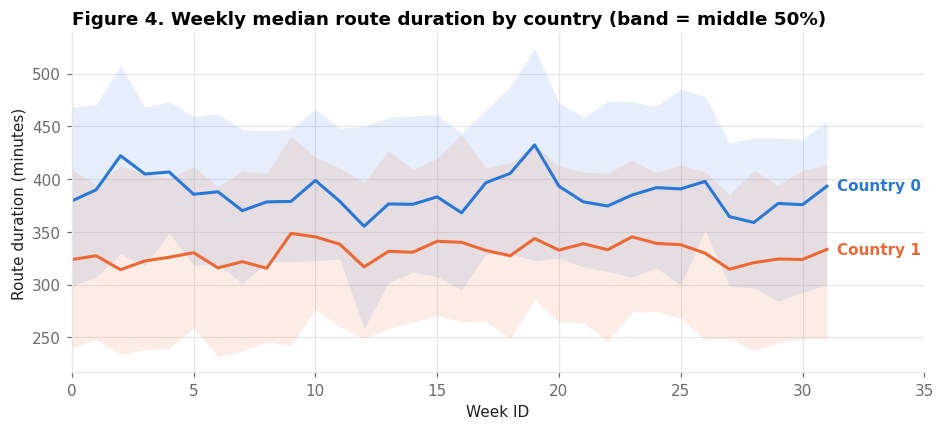

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig04_weekly_duration.png
Median duration, weeks 0-7   : 356.6 min
Median duration, weeks 24-31 : 346.5 min


In [14]:
weekly = routes_clean.groupby(['country', 'week_id'])[TARGET].describe()[['count', '25%', '50%', '75%']]

fig, ax = plt.subplots(figsize=(10, 4))
for country, color in [(0, BLUE), (1, ORANGE)]:
    w = weekly.loc[country]
    ax.fill_between(w.index, w['25%'], w['75%'], color=color, alpha=0.12, linewidth=0)
    ax.plot(w.index, w['50%'], color=color, linewidth=2)
    ax.text(w.index[-1] + 0.4, w['50%'].iloc[-1], f'Country {country}', color=color,
            va='center', fontweight='bold')
ax.set_xlim(0, 35)
ax.set_title('Figure 4. Weekly median route duration by country (band = middle 50%)')
ax.set_xlabel('Week ID')
ax.set_ylabel('Route duration (minutes)')
save_figure(fig, 'fig04_weekly_duration.png')

first, last = routes_clean['week_id'] <= 7, routes_clean['week_id'] >= 24
print(f'Median duration, weeks 0-7   : {routes_clean.loc[first, TARGET].median():.1f} min')
print(f'Median duration, weeks 24-31 : {routes_clean.loc[last, TARGET].median():.1f} min')

## 8. Chronological train, validation and test split

The routes are in date order, so the data is split by week rather than at random. This mirrors real use: a
planning tool is trained on past routes and then predicts routes that happen later. A random split would let the
model learn from routes that happen after the ones it is tested on, which makes the results look better than they
would be in practice.

| Set | Weeks | Purpose |
|---|---|---|
| Training | 0–21 | Fit every model |
| Validation | 22–25 | Compare settings while tuning each model |
| Test | 26–31 | Used once, at the end, to report final results |

The last two test routes are set aside as "future" routes and are only used in Section 14 to show how the final
model would be used on new routes.

`driver_id` itself is not used as a feature: it has 400 levels, and some drivers in the later weeks never appear in
the training weeks. The driver's history is represented by `driver_prior_routes` instead.

In [15]:
FEATURES = FEATURES_NUM + FEATURES_CAT
TRAIN_WEEKS, VAL_WEEKS, TEST_WEEKS = range(0, 22), range(22, 26), range(26, 32)

train_df = routes_clean[routes_clean['week_id'].isin(TRAIN_WEEKS)].reset_index(drop=True)
val_df = routes_clean[routes_clean['week_id'].isin(VAL_WEEKS)].reset_index(drop=True)
test_all = routes_clean[routes_clean['week_id'].isin(TEST_WEEKS)].reset_index(drop=True)
future_df = test_all.tail(2).reset_index(drop=True)
test_df = test_all.iloc[:-2].reset_index(drop=True)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_val, y_val = val_df[FEATURES], val_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

split_summary = pd.DataFrame({
    'weeks': ['0-21', '22-25', '26-31', '31'],
    'routes': [len(train_df), len(val_df), len(test_df), len(future_df)],
    'share': [len(d) / len(routes_clean) for d in (train_df, val_df, test_df, future_df)],
    'median duration': [d[TARGET].median() for d in (train_df, val_df, test_df, future_df)],
    'mean duration': [d[TARGET].mean() for d in (train_df, val_df, test_df, future_df)],
}, index=['train', 'validation', 'test', 'future'])
display(split_summary.style.format({'share': '{:.1%}', 'median duration': '{:.1f}', 'mean duration': '{:.1f}'}))

seen_drivers = set(train_df['driver_id'])
print(f"Test routes whose driver never appears in training: {(~test_df['driver_id'].isin(seen_drivers)).mean():.1%}")

assert len(train_df) + len(val_df) + len(test_df) + len(future_df) == len(routes_clean)
assert train_df['week_id'].max() < val_df['week_id'].min()
assert val_df['week_id'].max() < test_df['week_id'].min()
assert set(train_df['Route ID']).isdisjoint(set(test_df['Route ID']) | set(val_df['Route ID']))

,weeks,routes,share,median duration,mean duration
train,0-21,10882,67.8%,355.4,360.8
validation,22-25,2333,14.5%,353.2,361.5
test,26-31,2831,17.6%,344.0,345.9
future,31,2,0.0%,302.0,302.0


Test routes whose driver never appears in training: 7.8%


### Pre-processing

Every model receives the same pre-processing, built inside a scikit-learn `Pipeline` so that it is learned from the
training weeks only and then applied unchanged to the validation and test weeks:

- **Numeric features** are standardised (mean 0, standard deviation 1). Linear regression and neural networks
  need features on a similar scale; tree-based models are unaffected by it.
- **Categorical features** (`country`, `weekday`) are one-hot encoded. A category not seen in training would be
  encoded as all zeros instead of causing an error.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

def make_preprocessor():
    return ColumnTransformer([
        ('num', StandardScaler(), FEATURES_NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT),
    ])

preview = make_preprocessor().fit(X_train)
print('Model inputs after pre-processing:', len(preview.get_feature_names_out()))
print(list(preview.get_feature_names_out()))

Model inputs after pre-processing: 21
['num__n_stops', 'num__n_depot_visits', 'num__n_pickups', 'num__n_addresses', 'num__planned_km', 'num__max_leg_km', 'num__first_leg_km', 'num__earliest_start', 'num__latest_end', 'num__mean_window', 'num__min_window', 'num__driver_prior_routes', 'cat__country_0', 'cat__country_1', 'cat__weekday_Friday', 'cat__weekday_Monday', 'cat__weekday_Saturday', 'cat__weekday_Sunday', 'cat__weekday_Thursday', 'cat__weekday_Tuesday', 'cat__weekday_Wednesday']


## 9. Baseline model

A model is only useful if it beats a simple alternative. **Linear regression** is used as the baseline: it
combines the same features in a straight line, so the two AI techniques must beat it to justify their extra
complexity. Comparison with simply predicting the average duration is already built into R², where 0 means no
better than the average.

The test set stays unused here; the baseline is scored on the validation weeks, like every model during
development.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, median_absolute_error

def score(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'MedAE': median_absolute_error(y_true, y_pred),
    }

baselines = {
    'Linear regression': Pipeline([('prep', make_preprocessor()), ('model', LinearRegression())]),
}

rows = {}
for name, pipe in baselines.items():
    pipe.fit(X_train, y_train)
    rows[(name, 'train')] = score(y_train, pipe.predict(X_train))
    rows[(name, 'validation')] = score(y_val, pipe.predict(X_val))

baseline_results = pd.DataFrame(rows).T
baseline_results.index.names = ['model', 'set']
baseline_results.to_csv(os.path.join(RESULTS_DIR, 'baseline_validation.csv'))
display(baseline_results.round(3))

MAE  RMSE   R2  MedAE
model             set                               
Linear regression train      68.68 89.45 0.44  55.55
                  validation 71.07 90.29 0.44  59.76

### What linear regression learned

The coefficients of the linear model show how many minutes each feature adds per one standard deviation
(numeric features) or for belonging to a category (one-hot features). They show which planned information the
simplest model relies on.

In [18]:
lin = baselines['Linear regression']
coefficients = pd.Series(lin.named_steps['model'].coef_,
                         index=lin.named_steps['prep'].get_feature_names_out()).sort_values(key=abs, ascending=False)
display(coefficients.round(1).to_frame('minutes per unit'))

,minutes per unit
num__planned_km,40.50
num__n_addresses,37.00
cat__country_1,-31.60
cat__country_0,31.60
num__mean_window,-16.50
num__latest_end,16.10
cat__weekday_Saturday,13.30
num__n_pickups,12.10
num__n_stops,9.50
cat__weekday_Sunday,-8.90


## 10. Model development and tuning

### 10.1 Screening candidate techniques with lab settings

Six regression techniques covered in the labs are first run with the settings used in the labs. This shows how
each technique performs "out of the box", and gives a reference point for how much tuning helps each one. Every
technique is then tuned in Section 10.2, because the lab settings are not equally suitable for this problem.

| Technique | Lab | Settings used for screening |
|---|---|---|
| Decision tree | Lab 3 | `max_depth=4` |
| Random forest | Lab 3 | 100 trees |
| Gradient boosting | Lab 3 | 100 trees, learning rate 0.1, depth 3 |
| K-nearest neighbours | Lab 3 | 5 neighbours |
| Support vector regression | Lab 3 | RBF kernel, `C=1.0`, `epsilon=0.1` |
| Feed-forward neural network | Lab 5 | 3 hidden layers (512, 512, 100, ReLU), Adam, MSE loss, 20 epochs, batch size 32 (Lab 5 used 10, changed to shorten run time) |

In [19]:
import time
import tensorflow as tf
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

REUSE_SAVED_RESULTS = True

class KerasFNN(BaseEstimator, RegressorMixin):
    def __init__(self, hidden=(512, 512, 100), dropout=0.0, learning_rate=1e-3, epochs=20,
                 batch_size=32, early_stopping=False, seed=SEED):
        self.hidden = hidden
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.seed = seed

    def fit(self, X, y):
        tf.keras.utils.set_random_seed(self.seed)
        X = np.asarray(X, dtype='float32')
        y = np.asarray(y, dtype='float32').ravel()
        model = tf.keras.Sequential([tf.keras.Input(shape=(X.shape[1],))])
        for units in self.hidden:
            model.add(tf.keras.layers.Dense(units, activation='relu'))
            if self.dropout > 0:
                model.add(tf.keras.layers.Dropout(self.dropout))
        model.add(tf.keras.layers.Dense(1))
        model.compile(optimizer=tf.keras.optimizers.Adam(self.learning_rate), loss='mse')
        callbacks, split = [], 0.0
        if self.early_stopping:
            split = 0.1
            callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                                          restore_best_weights=True)]
        self.history_ = model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size,
                                  validation_split=split, callbacks=callbacks, verbose=0).history
        self.model_ = model
        return self

    def predict(self, X):
        return self.model_.predict(np.asarray(X, dtype='float32'), verbose=0).ravel()

def make_pipeline(regressor):
    return Pipeline([
        ('prep', make_preprocessor()),
        ('model', TransformedTargetRegressor(regressor=regressor, transformer=StandardScaler())),
    ])

dev_df = pd.concat([train_df, val_df], ignore_index=True)
FOLDS = [(range(0, 10), range(10, 14)), (range(0, 14), range(14, 18)),
         (range(0, 18), range(18, 22)), (range(0, 22), range(22, 26))]

def evaluate_on_folds(regressor):
    rows = []
    for fold, (fit_weeks, check_weeks) in enumerate(FOLDS, start=1):
        fit_part = dev_df[dev_df['week_id'].isin(fit_weeks)]
        check_part = dev_df[dev_df['week_id'].isin(check_weeks)]
        pipe = make_pipeline(regressor)
        start = time.perf_counter()
        pipe.fit(fit_part[FEATURES], fit_part[TARGET])
        seconds = time.perf_counter() - start
        rows.append({'fold': fold, **score(check_part[TARGET], pipe.predict(check_part[FEATURES])),
                     'fit seconds': seconds})
    return pd.DataFrame(rows)

print(f'TensorFlow {tf.__version__}')
print('Folds:', [(len(dev_df[dev_df.week_id.isin(a)]), len(dev_df[dev_df.week_id.isin(b)])) for a, b in FOLDS])

TensorFlow 2.20.0
Folds: [(4610, 2043), (6653, 2195), (8848, 2034), (10882, 2333)]


In [20]:
candidates = {
    'Linear regression': LinearRegression(),
    'Decision tree': DecisionTreeRegressor(max_depth=4, random_state=SEED),
    'Random forest': RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                                   random_state=SEED),
    'K-nearest neighbours': KNeighborsRegressor(n_neighbors=5),
    'Support vector regression': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Neural network (FNN)': KerasFNN(hidden=(512, 512, 100), epochs=20, batch_size=32),
}

SCREEN_FILE = os.path.join(RESULTS_DIR, 'screening_4folds_lab_settings.csv')
if REUSE_SAVED_RESULTS and os.path.exists(SCREEN_FILE):
    screening = pd.read_csv(SCREEN_FILE)
    print('Loaded:', SCREEN_FILE)
else:
    parts = []
    for name, regressor in candidates.items():
        result = evaluate_on_folds(regressor)
        result.insert(0, 'model', name)
        parts.append(result)
        print(f"{name:<27} mean MAE {result['MAE'].mean():6.2f}   {result['fit seconds'].sum():6.1f} s")
    screening = pd.concat(parts, ignore_index=True)
    screening.to_csv(SCREEN_FILE, index=False)
    print('Saved:', SCREEN_FILE)

screening_summary = (screening.groupby('model')
                     .agg(MAE_mean=('MAE', 'mean'), MAE_std=('MAE', 'std'), RMSE_mean=('RMSE', 'mean'),
                          R2_mean=('R2', 'mean'), fit_seconds=('fit seconds', 'mean'))
                     .sort_values('MAE_mean'))
display(screening_summary.round(2))
display(screening.pivot(index='model', columns='fold', values='MAE').loc[screening_summary.index].round(2))

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/screening_4folds_lab_settings.csv


,MAE_mean,MAE_std,RMSE_mean,R2_mean,fit_seconds
model,,,,,
Support vector regression,64.51,1.80,86.00,0.49,4.28
Random forest,64.60,2.79,84.94,0.50,11.44
Gradient boosting,66.44,1.90,86.21,0.49,2.18
Linear regression,70.38,2.36,90.61,0.43,0.20
K-nearest neighbours,70.39,2.59,92.20,0.41,0.02
Neural network (FNN),75.56,2.26,99.22,0.32,41.71
Decision tree,77.25,1.82,99.03,0.32,0.08


fold,1,2,3,4
model,,,,
Support vector regression,66.36,64.45,65.15,62.09
Random forest,67.95,62.93,65.76,61.77
Gradient boosting,67.34,64.65,68.67,65.09
Linear regression,67.72,69.48,73.27,71.07
K-nearest neighbours,73.75,69.63,70.68,67.52
Neural network (FNN),78.77,75.10,74.92,73.45
Decision tree,76.00,75.93,79.83,77.23


### 10.2 Tuning every candidate technique

**Equal tuning budget.** Each technique gets the same search: 20 settings drawn at random with a fixed seed, each
scored on the same four time-ordered folds, ranked by mean MAE. Linear regression has no hyperparameters to tune
and stays as the baseline.

| Technique | Hyperparameters searched | Why these |
|---|---|---|
| Support vector regression | `C` (0.1–20, log scale), `epsilon` (0.02–0.5), `gamma` | `C` trades fit against smoothness, `epsilon` sets the error band that is ignored, `gamma` sets how local the RBF kernel is |
| Random forest | number of trees, maximum depth, minimum samples per leaf, share of features per split | Depth and leaf size control over-fitting; fewer features per split makes trees more different from each other |
| Gradient boosting | number of trees, learning rate, tree depth, subsample share, minimum samples per leaf | A lower learning rate needs more trees; subsampling and leaf size reduce over-fitting |
| Decision tree | maximum depth, minimum samples per leaf and per split, share of features per split | The lab depth of 4 is very shallow for 21 inputs, so the depth limit is the main thing to search |
| K-nearest neighbours | number of neighbours, distance weighting, distance measure | More neighbours smooth the prediction; distance weighting lets closer routes count more |
| Feed-forward neural network | layer sizes, dropout, learning rate, batch size | The lab network is too large for this data, so smaller networks and dropout are searched, with early stopping so the number of epochs is chosen automatically |


In [21]:
import ast
from scipy.stats import loguniform, uniform, randint
from sklearn.model_selection import RandomizedSearchCV

N_SETTINGS = 20
CV_SPLITS = [(np.where(dev_df['week_id'].isin(a))[0], np.where(dev_df['week_id'].isin(b))[0]) for a, b in FOLDS]
X_dev, y_dev = dev_df[FEATURES], dev_df[TARGET]

search_spaces = {
    'Support vector regression': (SVR(kernel='rbf'), {
        'C': loguniform(0.1, 20),
        'epsilon': uniform(0.02, 0.48),
        'gamma': ['scale', 0.01, 0.03, 0.1],
    }),
    'Random forest': (RandomForestRegressor(random_state=SEED, n_jobs=-1), {
        'n_estimators': randint(100, 401),
        'max_depth': [None, 8, 12, 16, 20],
        'min_samples_leaf': [1, 2, 5, 10, 20],
        'max_features': [1.0, 0.7, 0.5, 'sqrt'],
    }),
    'Gradient boosting': (GradientBoostingRegressor(random_state=SEED), {
        'n_estimators': randint(100, 601),
        'learning_rate': loguniform(0.01, 0.2),
        'max_depth': [2, 3, 4, 5, 6],
        'subsample': [0.7, 0.85, 1.0],
        'min_samples_leaf': [1, 5, 20, 50],
    }),
    'Decision tree': (DecisionTreeRegressor(random_state=SEED), {
        'max_depth': [None, 4, 6, 8, 10, 12, 16, 20],
        'min_samples_leaf': [1, 2, 5, 10, 20, 50],
        'min_samples_split': [2, 5, 10, 20, 50],
        'max_features': [1.0, 0.7, 0.5],
    }),
    'K-nearest neighbours': (KNeighborsRegressor(), {
        'n_neighbors': randint(3, 60),
        'weights': ['uniform', 'distance'],
        'p': [1, 2],
    }),
    'Neural network (FNN)': (KerasFNN(epochs=200, early_stopping=True), {
        'hidden': [(64, 32), (128, 64), (256, 128), (128, 64, 32), (256, 128, 64), (512, 512, 100)],
        'dropout': [0.0, 0.1, 0.2, 0.3],
        'learning_rate': loguniform(1e-4, 1e-2),
        'batch_size': [32, 64, 128],
    }),
}

def run_search(name):
    regressor, space = search_spaces[name]
    slug = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    path = os.path.join(RESULTS_DIR, f'tuning_{slug}_{N_SETTINGS}x4folds.csv')
    if REUSE_SAVED_RESULTS and os.path.exists(path):
        print('Loaded:', path)
        return pd.read_csv(path)
    search = RandomizedSearchCV(
        make_pipeline(regressor),
        {f'model__regressor__{k}': v for k, v in space.items()},
        n_iter=N_SETTINGS, cv=CV_SPLITS, scoring='neg_mean_absolute_error',
        random_state=SEED, n_jobs=1 if 'Neural' in name else -1, refit=False,
    )
    start = time.perf_counter()
    search.fit(X_dev, y_dev)
    table = pd.DataFrame(search.cv_results_)
    table['MAE_mean'] = -table['mean_test_score']
    table['MAE_std'] = table['std_test_score']
    for i in range(len(FOLDS)):
        table[f'fold{i + 1}'] = -table[f'split{i}_test_score']
    params = [c for c in table.columns if c.startswith('param_')]
    table = table[params + ['MAE_mean', 'MAE_std'] + [f'fold{i + 1}' for i in range(len(FOLDS))]
                  + ['mean_fit_time']].sort_values('MAE_mean')
    table.columns = [c.replace('param_model__regressor__', '') for c in table.columns]
    table.to_csv(path, index=False)
    print(f'{name}: {time.perf_counter() - start:.0f} s, saved {path}')
    return table

tuning = {name: run_search(name) for name in search_spaces}
for name, table in tuning.items():
    print(f'\n{name} - best 5 of {N_SETTINGS} settings')
    display(table.head(5).round(3))

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_support_vector_regression_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_random_forest_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_gradient_boosting_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_decision_tree_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_k-nearest_neighbours_20x4folds.csv
Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/tuning_neural_network_fnn_20x4folds.csv

Support vector regression - best 5 of 20 settings


,C,epsilon,gamma,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,2.50,0.10,0.03,64.27,1.24,65.79,63.48,65.12,62.68,7.86
1,17.40,0.13,0.01,64.69,1.18,65.86,63.77,65.87,63.27,10.56
2,6.41,0.12,0.03,64.79,1.51,66.58,64.65,65.48,62.45,9.98
3,0.59,0.09,0.03,64.82,1.13,65.55,63.88,66.29,63.57,7.24
4,6.22,0.31,0.01,65.04,0.98,65.72,64.20,66.29,63.97,5.91



Random forest - best 5 of 20 settings


,max_depth,max_features,min_samples_leaf,n_estimators,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,20,sqrt,1,148,62.89,1.92,65.35,61.61,64.06,60.52,5.09
1,20,0.5,2,317,63.03,2.26,65.96,61.86,64.27,60.04,18.46
2,16,0.7,2,369,63.34,2.32,66.40,62.16,64.50,60.27,26.98
3,16,0.7,2,359,63.34,2.33,66.43,62.19,64.48,60.26,26.00
4,16,0.7,2,291,63.35,2.33,66.46,62.15,64.48,60.30,20.84



Gradient boosting - best 5 of 20 settings


...

,min_samples_split,min_samples_leaf,max_features,max_depth,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,50,20,0.70,NaN,70.68,2.46,74.55,70.06,70.37,67.73,0.12
1,2,20,1.00,8.00,71.32,1.59,73.67,69.98,71.86,69.75,0.15
2,10,20,1.00,8.00,71.32,1.59,73.67,69.98,71.86,69.75,0.17
3,20,50,0.50,10.00,71.97,1.90,73.83,71.22,73.65,69.20,0.10
4,20,50,0.70,8.00,72.22,1.67,74.94,71.36,72.06,70.52,0.06



K-nearest neighbours - best 5 of 20 settings


,n_neighbors,p,weights,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,18,1,distance,65.53,1.44,67.84,64.95,65.39,63.93,0.02
1,17,1,distance,65.56,1.40,67.81,65.07,65.41,63.97,0.02
2,24,1,distance,65.66,1.43,67.84,64.90,65.89,64.00,0.03
3,23,1,distance,65.66,1.45,67.92,64.90,65.83,64.01,0.02
4,23,1,distance,65.66,1.45,67.92,64.90,65.83,64.01,0.02



Neural network (FNN) - best 5 of 20 settings


,batch_size,dropout,hidden,learning_rate,MAE_mean,MAE_std,fold1,fold2,fold3,fold4,mean_fit_time
0,128,0.20,"(256, 128, 64)",0.00,66.16,1.23,67.61,66.21,66.58,64.22,12.88
1,64,0.10,"(128, 64)",0.00,66.19,1.24,66.47,67.67,66.41,64.24,26.14
2,128,0.30,"(512, 512, 100)",0.00,66.49,0.85,67.80,66.37,66.35,65.42,45.37
3,32,0.10,"(128, 64, 32)",0.00,66.57,0.69,66.52,67.08,67.21,65.46,31.24
4,64,0.10,"(512, 512, 100)",0.00,66.59,1.29,67.51,67.79,66.57,64.49,28.72


### 10.3 Choosing the two techniques to compare

Every technique has now been tuned with the same budget on the same folds, so the two with the lowest mean MAE
after tuning are carried forward to the final evaluation. The table also shows how much tuning changed each
technique, which is why tuning every candidate was necessary: the ranking after tuning is not the ranking before
it.

In [22]:
best_rows = []
for name, table in tuning.items():
    best = table.iloc[0]
    screen = screening_summary.loc[name, 'MAE_mean']
    best_rows.append({'model': name, 'screening MAE': screen, 'tuned MAE': best['MAE_mean'],
                      'improvement': screen - best['MAE_mean'], 'MAE std': best['MAE_std'],
                      **{f'fold {i + 1}': best[f'fold{i + 1}'] for i in range(len(FOLDS))},
                      'fit seconds': best['mean_fit_time']})
tuned_summary = pd.DataFrame(best_rows).set_index('model').sort_values('tuned MAE')
tuned_summary.to_csv(os.path.join(RESULTS_DIR, 'tuned_summary.csv'))
display(tuned_summary.round(2))

fold_cols = [f'fold {i + 1}' for i in range(len(FOLDS))]
print('Folds won:', tuned_summary[fold_cols].idxmin().value_counts().to_dict())

SELECTED = list(tuned_summary.index[:2])
print('Selected for final evaluation:', SELECTED)

INT_PARAMS = {'n_estimators', 'max_depth', 'min_samples_leaf', 'min_samples_split', 'n_neighbors',
              'batch_size', 'epochs', 'p'}

def best_params(name):
    row = tuning[name].iloc[0]
    params = {}
    for key in search_spaces[name][1]:
        value = row[key]
        if pd.isna(value):
            value = None
        elif isinstance(value, str):
            try:
                value = ast.literal_eval(value)
            except (ValueError, SyntaxError):
                pass
        elif hasattr(value, 'item'):
            value = value.item()
        if key in INT_PARAMS and value is not None:
            value = int(value)
        params[key] = value
    return params

BEST_PARAMS = {name: best_params(name) for name in SELECTED}
for name, params in BEST_PARAMS.items():
    print(f"{name}: { {k: round(v, 4) if isinstance(v, float) else v for k, v in params.items()} }")

,screening MAE,tuned MAE,improvement,MAE std,fold 1,fold 2,fold 3,fold 4,fit seconds
model,,,,,,,,,
Random forest,64.60,62.89,1.72,1.92,65.35,61.61,64.06,60.52,5.09
Gradient boosting,66.44,63.75,2.69,1.57,65.35,62.85,65.16,61.63,9.48
Support vector regression,64.51,64.27,0.25,1.24,65.79,63.48,65.12,62.68,7.86
K-nearest neighbours,70.39,65.52,4.87,1.44,67.84,64.95,65.39,63.93,0.02
Neural network (FNN),75.56,66.16,9.40,1.23,67.61,66.21,66.58,64.22,12.88
Decision tree,77.25,70.68,6.57,2.46,74.55,70.06,70.37,67.73,0.13


Folds won: {'Random forest': 3, 'Gradient boosting': 1}
Selected for final evaluation: ['Random forest', 'Gradient boosting']
Random forest: {'n_estimators': 148, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Gradient boosting: {'n_estimators': 206, 'learning_rate': 0.0307, 'max_depth': 6, 'subsample': 0.7, 'min_samples_leaf': 20}


## 11. Final evaluation on the test set

The two selected techniques and the linear regression baseline are now trained once more, on all development
weeks (0–25), and scored once on the untouched test weeks (26–31). Each model keeps the setting chosen in
Section 10; nothing is changed after seeing the test results.

Besides accuracy, the table records the cost of each model: training time, the time to predict all test routes,
and the size of the saved model. To check consistency, the two tree ensembles are also retrained with five
different random seeds; a model whose error changes a lot between seeds is less dependable.

In [23]:
import sklearn, pickle
print(f'scikit-learn {sklearn.__version__}')

final_regressors = {
    'Linear regression': LinearRegression(),
    'Random forest': RandomForestRegressor(**BEST_PARAMS['Random forest'], random_state=SEED, n_jobs=-1),
    'Gradient boosting': GradientBoostingRegressor(**BEST_PARAMS['Gradient boosting'], random_state=SEED),
}

final_models, test_predictions, test_rows = {}, {}, []
for name, regressor in final_regressors.items():
    pipe = make_pipeline(regressor)
    start = time.perf_counter()
    pipe.fit(X_dev, y_dev)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    prediction = pipe.predict(X_test)
    predict_seconds = time.perf_counter() - start
    final_models[name] = pipe
    test_predictions[name] = prediction
    test_rows.append({'model': name, **score(y_test, prediction), 'fit seconds': fit_seconds,
                      'predict ms per route': 1000 * predict_seconds / len(X_test),
                      'model size MB': len(pickle.dumps(pipe)) / 1e6})

test_results = pd.DataFrame(test_rows).set_index('model')
test_results.to_csv(os.path.join(RESULTS_DIR, 'test_results.csv'))
display(test_results.round(3))

lin_mae = test_results.loc['Linear regression', 'MAE']
for name in SELECTED:
    gain = lin_mae - test_results.loc[name, 'MAE']
    print(f'{name}: {gain:.1f} min lower MAE than linear regression ({gain / lin_mae:.1%})')

scikit-learn 1.6.1


,MAE,RMSE,R2,MedAE,fit seconds,predict ms per route,model size MB
model,,,,,,,
Linear regression,70.47,89.21,0.45,60.48,0.14,0.01,0.00
Random forest,60.95,79.12,0.56,48.74,8.92,0.08,146.70
Gradient boosting,61.38,79.30,0.56,50.52,13.42,0.01,1.29


Random forest: 9.5 min lower MAE than linear regression (13.5%)
Gradient boosting: 9.1 min lower MAE than linear regression (12.9%)


### 11.1 Consistency across random seeds

Random forest and gradient boosting both use randomness (random subsets of routes and features). Retraining them
with five seeds shows how much the test error depends on luck.

In [24]:
SEEDS = [0, 1, 2, 3, 4]
SEED_FILE = os.path.join(RESULTS_DIR, 'seed_check_5seeds.csv')
if os.path.exists(SEED_FILE):
    seed_check = pd.read_csv(SEED_FILE)
    print('Loaded:', SEED_FILE)
else:
    seed_rows = []
    for seed in SEEDS:
        for name, regressor in [
            ('Random forest', RandomForestRegressor(**BEST_PARAMS['Random forest'], random_state=seed, n_jobs=-1)),
            ('Gradient boosting', GradientBoostingRegressor(**BEST_PARAMS['Gradient boosting'], random_state=seed)),
        ]:
            pipe = make_pipeline(regressor).fit(X_dev, y_dev)
            seed_rows.append({'model': name, 'seed': seed, **score(y_test, pipe.predict(X_test))})
    seed_check = pd.DataFrame(seed_rows)
    seed_check.to_csv(SEED_FILE, index=False)
    print('Saved:', SEED_FILE)

seed_summary = seed_check.groupby('model')['MAE'].agg(['mean', 'std', 'min', 'max'])
seed_summary['range'] = seed_summary['max'] - seed_summary['min']
display(seed_summary.round(3))

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/seed_check_5seeds.csv


,mean,std,min,max,range
model,,,,,
Gradient boosting,61.30,0.14,61.09,61.47,0.37
Random forest,61.13,0.27,60.77,61.40,0.63


## 12. Statistical comparison

A lower average error on one test set does not prove that one model is better; the difference could come from a
few routes. Each model's absolute error is paired route by route, and the **Wilcoxon signed-rank test** checks
whether one model's errors are consistently smaller. This test is used instead of a paired t-test because the
error differences are not normally distributed (checked below with the Shapiro–Wilk test on a sample).

Three comparisons are made, and the Holm correction adjusts the p-values for making more than one test:

1. Random forest vs gradient boosting — which selected technique is better?
2. Random forest vs linear regression — does the first technique beat the simple baseline?
3. Gradient boosting vs linear regression — does the second technique beat the simple baseline?

The median paired difference (in minutes) shows how large each difference is, not only whether it is
significant. A second view counts how many of the six test weeks each model wins.

In [25]:
from scipy.stats import wilcoxon, shapiro

abs_errors = pd.DataFrame({name: np.abs(y_test.values - pred) for name, pred in test_predictions.items()})

pairs = [('Random forest', 'Gradient boosting'),
         ('Random forest', 'Linear regression'),
         ('Gradient boosting', 'Linear regression')]

rng = np.random.default_rng(SEED)
stat_rows = []
for a, b in pairs:
    diff = abs_errors[a] - abs_errors[b]
    sample = rng.choice(diff.values, size=500, replace=False)
    stat, p = wilcoxon(abs_errors[a], abs_errors[b])
    stat_rows.append({'comparison': f'{a} vs {b}', 'MAE A': abs_errors[a].mean(), 'MAE B': abs_errors[b].mean(),
                      'median difference (A-B)': diff.median(), 'A better on routes': (diff < 0).mean(),
                      'Shapiro p (normality)': shapiro(sample).pvalue, 'Wilcoxon p': p})

stats_table = pd.DataFrame(stat_rows).set_index('comparison').sort_values('Wilcoxon p')
m = len(stats_table)
holm = (stats_table['Wilcoxon p'] * np.arange(m, 0, -1)).cummax().clip(upper=1)
stats_table['Holm p'] = holm
stats_table['significant (0.05)'] = stats_table['Holm p'] < 0.05
stats_table = stats_table.loc[[f'{a} vs {b}' for a, b in pairs]]
stats_table.to_csv(os.path.join(RESULTS_DIR, 'wilcoxon_tests.csv'))
display(stats_table.style.format({'MAE A': '{:.2f}', 'MAE B': '{:.2f}', 'median difference (A-B)': '{:.2f}',
                                  'A better on routes': '{:.1%}', 'Shapiro p (normality)': '{:.2e}',
                                  'Wilcoxon p': '{:.2e}', 'Holm p': '{:.2e}'}))

weekly_mae = (abs_errors.assign(week_id=test_df['week_id'].values)
              .groupby('week_id')[['Linear regression', 'Random forest', 'Gradient boosting']].mean())
weekly_mae['best'] = weekly_mae.idxmin(axis=1)
display(weekly_mae.round(2))
print('Weeks won:', weekly_mae['best'].value_counts().to_dict())

,MAE A,MAE B,median difference (A-B),A better on routes,Shapiro p (normality),Wilcoxon p,Holm p,significant (0.05)
comparison,,,,,,,,
Random forest vs Gradient boosting,60.95,61.38,-0.21,50.7%,1.18e-07,3.12e-01,3.12e-01,False
Random forest vs Linear regression,60.95,70.47,-7.65,60.7%,1.55e-10,3.90e-44,7.81e-44,True
Gradient boosting vs Linear regression,61.38,70.47,-8.41,60.8%,2.65e-13,8.00e-46,2.40e-45,True


,Linear regression,Random forest,Gradient boosting,best
week_id,,,,
26,70.35,59.06,60.13,Random forest
27,70.45,60.26,61.07,Random forest
28,70.30,59.45,59.18,Gradient boosting
29,68.04,62.58,62.73,Random forest
30,69.56,61.15,61.48,Random forest
31,75.68,64.10,64.58,Random forest


Weeks won: {'Random forest': 5, 'Gradient boosting': 1}


## 13. Figures

The figures below explain the test results. They all use the test weeks only, and the same colours throughout:
grey for linear regression, blue for random forest and orange for gradient boosting.

In [26]:
MODEL_COLORS = {'Linear regression': '#8c8c8c', 'Random forest': BLUE, 'Gradient boosting': ORANGE}
FINALISTS = SELECTED
print('Colours:', MODEL_COLORS)
print('Finalists:', FINALISTS)

Colours: {'Linear regression': '#8c8c8c', 'Random forest': '#2a78d6', 'Gradient boosting': '#eb6834'}
Finalists: ['Random forest', 'Gradient boosting']


### 13.1 Predicted against actual duration

A perfect model would put every route on the dashed diagonal. The density shows where most routes fall, and the
line shows the median prediction for each band of actual durations.

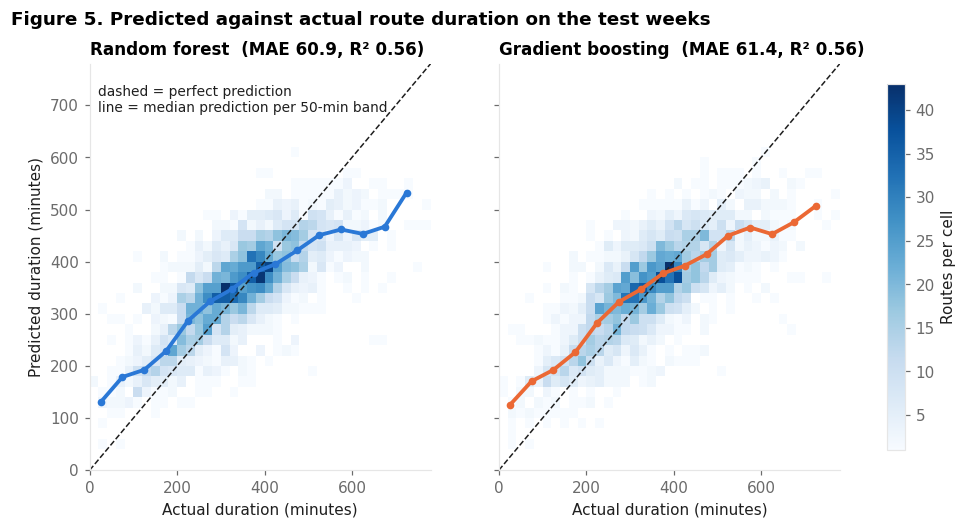

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig05_predicted_vs_actual.png
Random forest: mean error on routes under 200 min +75.9 min, over 550 min -148.4 min
Gradient boosting: mean error on routes under 200 min +69.8 min, over 550 min -146.0 min


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
edges = np.arange(0, 800, 20)
band_edges = np.arange(0, 800, 50)
for ax, name in zip(axes, FINALISTS):
    pred = test_predictions[name]
    counts, _, _, image = ax.hist2d(y_test, pred, bins=[edges, edges], cmap='Blues', cmin=1)
    ax.plot([0, 780], [0, 780], color=INK, linestyle='--', linewidth=1)
    band = pd.Series(pred).groupby(pd.cut(y_test.values, band_edges), observed=True).median()
    ax.plot([b.mid for b in band.index], band.values, color=MODEL_COLORS[name], linewidth=2.5, marker='o', markersize=4)
    r = test_results.loc[name]
    ax.set_title(f"{name}  (MAE {r['MAE']:.1f}, R² {r['R2']:.2f})", fontsize=11)
    ax.set_xlabel('Actual duration (minutes)')
    ax.grid(False)
axes[0].set_ylabel('Predicted duration (minutes)')
axes[0].text(20, 740, 'dashed = perfect prediction\nline = median prediction per 50-min band', color=INK, fontsize=9, va='top')
fig.suptitle('Figure 5. Predicted against actual route duration on the test weeks',
             x=0.06, ha='left', fontweight='bold', fontsize=12)
fig.colorbar(image, ax=axes, label='Routes per cell', shrink=0.9)
save_figure(fig, 'fig05_predicted_vs_actual.png')

for name in FINALISTS:
    pred = test_predictions[name]
    short, long_ = y_test < 200, y_test > 550
    print(f"{name}: mean error on routes under 200 min {np.mean(pred[short] - y_test[short]):+.1f} min, "
          f"over 550 min {np.mean(pred[long_] - y_test[long_]):+.1f} min")

### 13.2 Residuals

A residual is actual minus predicted duration. Plotting residuals against the prediction checks whether the errors
are balanced around zero for every size of route; the band shows where the middle 50% of residuals lie.

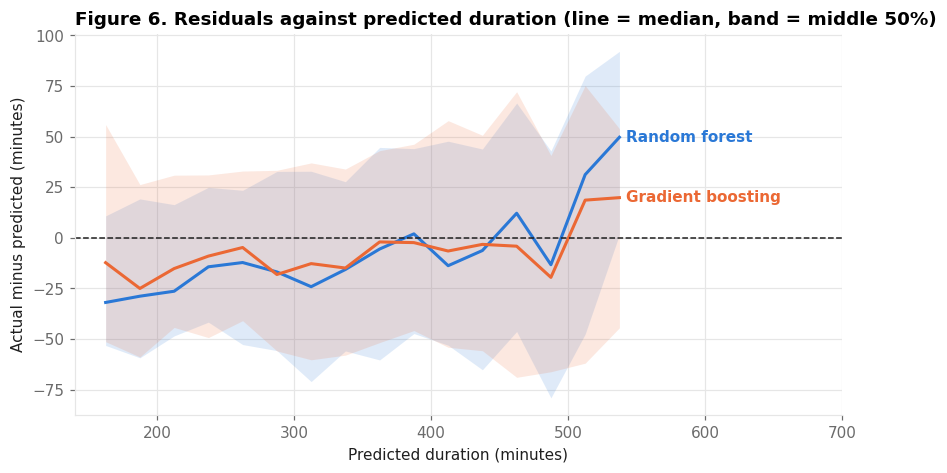

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig06_residuals.png


,count,mean,std,min,5%,25%,50%,75%,95%,max
Random forest,"2,831.00",-5.90,78.90,-297.10,-125.00,-56.40,-11.80,39.70,131.60,422.30
Gradient boosting,"2,831.00",-3.20,79.30,-289.10,-122.20,-54.90,-9.10,44.00,132.30,410.60


In [28]:
fig, ax = plt.subplots(figsize=(9, 4.5))
pred_edges = np.arange(100, 700, 25)
for name in FINALISTS:
    pred = test_predictions[name]
    resid = y_test.values - pred
    groups = pd.Series(resid).groupby(pd.cut(pred, pred_edges), observed=True)
    q = groups.quantile([0.25, 0.5, 0.75]).unstack()
    q = q[groups.size() >= 20]
    centres = [b.mid for b in q.index]
    ax.fill_between(centres, q[0.25], q[0.75], color=MODEL_COLORS[name], alpha=0.15, linewidth=0)
    ax.plot(centres, q[0.5], color=MODEL_COLORS[name], linewidth=2)
    ax.text(centres[-1] + 5, q[0.5].iloc[-1], name, color=MODEL_COLORS[name], va='center', fontweight='bold')
ax.axhline(0, color=INK, linewidth=1, linestyle='--')
ax.set_xlim(140, 700)
ax.set_title('Figure 6. Residuals against predicted duration (line = median, band = middle 50%)')
ax.set_xlabel('Predicted duration (minutes)')
ax.set_ylabel('Actual minus predicted (minutes)')
save_figure(fig, 'fig06_residuals.png')

resid_table = pd.DataFrame({name: y_test.values - test_predictions[name] for name in FINALISTS}).describe(
    percentiles=[.05, .25, .5, .75, .95]).T
display(resid_table.round(1))

### 13.3 Where are the errors largest?

The test routes are split by country and by number of stops, and the MAE of each model is compared within each
group. This shows whether the improvement over linear regression holds for every kind of route.

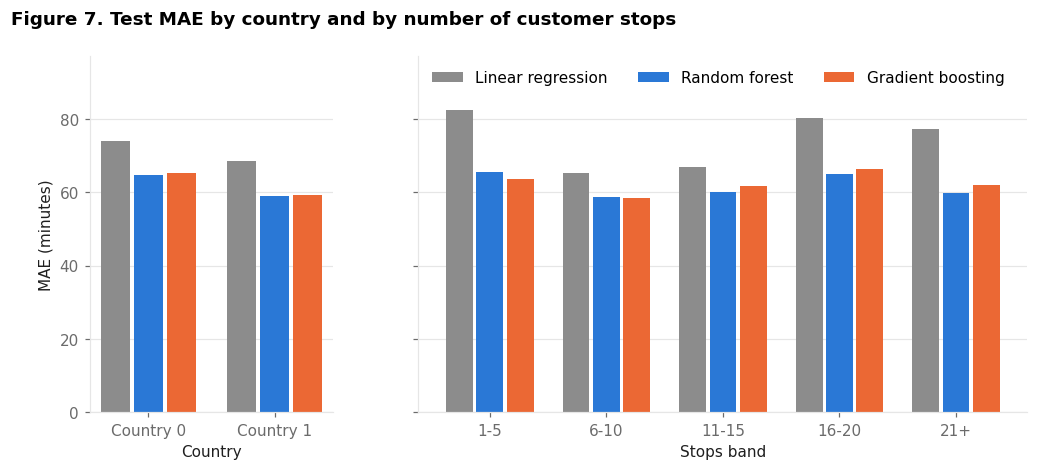

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig07_error_by_segment.png


Linear regression  Random forest  Gradient boosting  \
country    Country 0              74.10          64.80              65.20   
           Country 1              68.50          58.90              59.30   
stops band 1-5                    82.60          65.60              63.50   
           6-10                   65.20          58.60              58.50   
           11-15                  66.90          60.10              61.60   
           16-20                  80.20          65.00              66.40   
           21+                    77.40          59.70              62.10   

                      routes  
country    Country 0     986  
           Country 1    1845  
stops band 1-5           383  
           6-10         1031  
           11-15         956  
           16-20         374  
           21+            87

In [29]:
segments = test_df[['country', 'n_stops']].copy()
segments['stops band'] = pd.cut(segments['n_stops'], [0, 5, 10, 15, 20, 40], labels=['1-5', '6-10', '11-15', '16-20', '21+'])
segments['country'] = 'Country ' + segments['country'].astype(str)
models3 = ['Linear regression'] + FINALISTS

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, gridspec_kw={'width_ratios': [2, 5]})
for ax, column in zip(axes, ['country', 'stops band']):
    table = abs_errors[models3].groupby(segments[column].values, observed=True).mean()
    x = np.arange(len(table))
    width = 0.26
    for i, name in enumerate(models3):
        ax.bar(x + (i - 1) * width, table[name], width=width - 0.03, color=MODEL_COLORS[name], label=name)
    ax.set_xticks(x, table.index)
    ax.set_xlabel(column.capitalize())
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('MAE (minutes)')
axes[1].legend(loc='upper left', ncols=3)
axes[1].set_ylim(0, axes[1].get_ylim()[1] * 1.12)
fig.suptitle('Figure 7. Test MAE by country and by number of customer stops',
             x=0.06, ha='left', fontweight='bold', fontsize=12)
save_figure(fig, 'fig07_error_by_segment.png')

segment_table = pd.concat({
    'country': abs_errors[models3].groupby(segments['country'].values).mean(),
    'stops band': abs_errors[models3].groupby(segments['stops band'].values, observed=True).mean(),
})
segment_table['routes'] = pd.concat([segments['country'].value_counts(),
                                     segments['stops band'].value_counts()]).reindex(segment_table.index.get_level_values(1)).values
display(segment_table.round(1))

### 13.4 Which features matter?

Permutation importance measures how much the test MAE gets worse when one feature's values are shuffled, which
breaks its link with duration. It is computed the same way for both models, so their importances can be compared
directly. Each feature is shuffled five times and the average increase in MAE is shown.

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/permutation_importance_test.csv


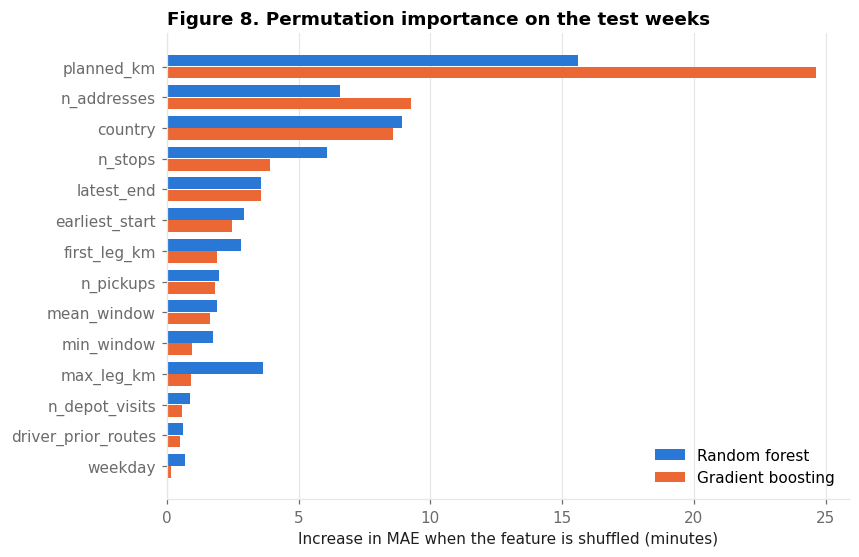

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig08_feature_importance.png


,Random forest,Gradient boosting
planned_km,15.61,24.65
n_addresses,6.58,9.26
country,8.92,8.59
n_stops,6.07,3.91
latest_end,3.59,3.59
earliest_start,2.92,2.47
first_leg_km,2.83,1.90
n_pickups,1.99,1.84
mean_window,1.90,1.65
min_window,1.76,0.95


In [30]:
from sklearn.inspection import permutation_importance

IMPORTANCE_FILE = os.path.join(RESULTS_DIR, 'permutation_importance_test.csv')
if os.path.exists(IMPORTANCE_FILE):
    importance = pd.read_csv(IMPORTANCE_FILE, index_col=0)
    print('Loaded:', IMPORTANCE_FILE)
else:
    importance = pd.DataFrame({
        name: permutation_importance(final_models[name], X_test, y_test, scoring='neg_mean_absolute_error',
                                     n_repeats=5, random_state=SEED, n_jobs=-1).importances_mean
        for name in FINALISTS}, index=FEATURES)
    importance.to_csv(IMPORTANCE_FILE)
    print('Saved:', IMPORTANCE_FILE)
importance = importance.sort_values('Gradient boosting')

fig, ax = plt.subplots(figsize=(8, 5.5))
y = np.arange(len(importance))
ax.barh(y + 0.2, importance['Random forest'], height=0.38, color=BLUE, label='Random forest')
ax.barh(y - 0.2, importance['Gradient boosting'], height=0.38, color=ORANGE, label='Gradient boosting')
ax.set_yticks(y, importance.index)
ax.axvline(0, color=MUTED, linewidth=1)
ax.grid(axis='y', visible=False)
ax.legend(loc='lower right')
ax.set_title('Figure 8. Permutation importance on the test weeks')
ax.set_xlabel('Increase in MAE when the feature is shuffled (minutes)')
save_figure(fig, 'fig08_feature_importance.png')

display(importance.sort_values('Gradient boosting', ascending=False).round(2))

### 13.5 Learning curve

Both models are retrained on growing shares of the development weeks (a random sample with a fixed seed) and
scored on the test weeks. The curve shows whether collecting more route history would still reduce the error.

Loaded: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/learning_curve_test.csv


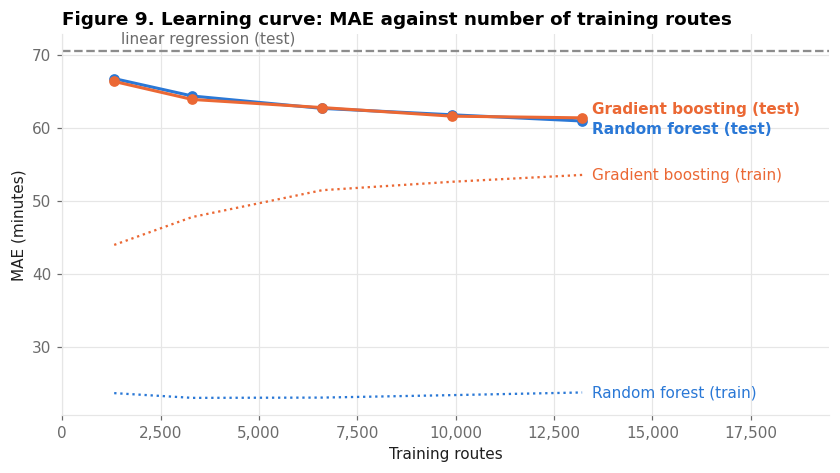

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig09_learning_curve.png


,model,share,routes,train MAE,test MAE
0,Random forest,0.10,1322,23.74,66.75
1,Gradient boosting,0.10,1322,44.01,66.36
2,Random forest,0.25,3304,23.09,64.37
3,Gradient boosting,0.25,3304,47.82,63.90
4,Random forest,0.50,6608,23.13,62.67
5,Gradient boosting,0.50,6608,51.49,62.79
6,Random forest,0.75,9911,23.46,61.80
7,Gradient boosting,0.75,9911,52.64,61.61
8,Random forest,1.00,13215,23.83,60.95
9,Gradient boosting,1.00,13215,53.58,61.38


In [31]:
from sklearn.base import clone

CURVE_FILE = os.path.join(RESULTS_DIR, 'learning_curve_test.csv')
SHARES = [0.1, 0.25, 0.5, 0.75, 1.0]
if os.path.exists(CURVE_FILE):
    curve = pd.read_csv(CURVE_FILE)
    print('Loaded:', CURVE_FILE)
else:
    curve_rows = []
    for share in SHARES:
        sample = dev_df.sample(frac=share, random_state=SEED) if share < 1 else dev_df
        for name in FINALISTS:
            pipe = make_pipeline(clone(final_regressors[name])).fit(sample[FEATURES], sample[TARGET])
            curve_rows.append({'model': name, 'share': share, 'routes': len(sample),
                               'train MAE': mean_absolute_error(sample[TARGET], pipe.predict(sample[FEATURES])),
                               'test MAE': mean_absolute_error(y_test, pipe.predict(X_test))})
    curve = pd.DataFrame(curve_rows)
    curve.to_csv(CURVE_FILE, index=False)
    print('Saved:', CURVE_FILE)

fig, ax = plt.subplots(figsize=(9, 4.5))
for name in FINALISTS:
    part = curve[curve['model'] == name]
    ax.plot(part['routes'], part['test MAE'], color=MODEL_COLORS[name], linewidth=2, marker='o', markersize=6)
    ax.plot(part['routes'], part['train MAE'], color=MODEL_COLORS[name], linewidth=1.5, linestyle=':')
    shift = -1.2 if name == 'Random forest' else 1.2
    ax.text(part['routes'].iloc[-1] + 250, part['test MAE'].iloc[-1] + shift, f'{name} (test)',
            color=MODEL_COLORS[name], va='center', fontweight='bold')
    ax.text(part['routes'].iloc[-1] + 250, part['train MAE'].iloc[-1], f'{name} (train)',
            color=MODEL_COLORS[name], va='center')
ax.axhline(test_results.loc['Linear regression', 'MAE'], color=MODEL_COLORS['Linear regression'], linestyle='--')
ax.text(1500, test_results.loc['Linear regression', 'MAE'] + 1, 'linear regression (test)',
        color=MUTED)
ax.set_xlim(0, 19500)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_title('Figure 9. Learning curve: MAE against number of training routes')
ax.set_xlabel('Training routes')
ax.set_ylabel('MAE (minutes)')
save_figure(fig, 'fig09_learning_curve.png')
display(curve.round(2))

### 13.6 Accuracy against cost

The last figure puts the evidence for the recommendation in one place: test MAE against training time and against
the size of the saved model. A model further left and lower is cheaper and more accurate.

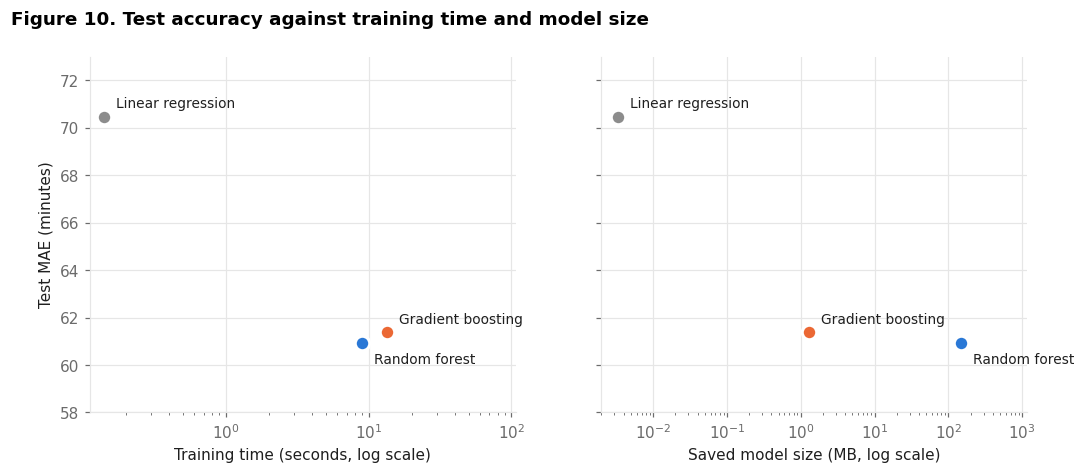

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/figures/fig10_accuracy_vs_cost.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, column, label in [(axes[0], 'fit seconds', 'Training time (seconds, log scale)'),
                          (axes[1], 'model size MB', 'Saved model size (MB, log scale)')]:
    for name in models3:
        r = test_results.loc[name]
        ax.scatter(r[column], r['MAE'], s=90, color=MODEL_COLORS[name], edgecolor='white', linewidth=2, zorder=3)
        offset = (8, -14) if name == 'Random forest' else (8, 6)
        ax.annotate(name, (r[column], r['MAE']), xytext=offset, textcoords='offset points', color=INK, fontsize=9)
    ax.set_xscale('log')
    ax.set_xlabel(label)
axes[0].set_ylabel('Test MAE (minutes)')
axes[0].set_ylim(58, 73)
axes[1].set_xlim(right=test_results['model size MB'].max() * 8)
axes[0].set_xlim(right=test_results['fit seconds'].max() * 8)
fig.suptitle('Figure 10. Test accuracy against training time and model size',
             x=0.06, ha='left', fontweight='bold', fontsize=12)
save_figure(fig, 'fig10_accuracy_vs_cost.png')

## 14. Predicting unseen routes

To show how the model would be used, the recommended model is saved to Google Drive, loaded back as a planning
tool would load it, and used to predict the two future routes that were held back in Section 8. Gradient boosting
is the recommended model: its accuracy is statistically tied with random forest (Section 12), but it is about 100
times smaller to store and more stable across random seeds (Sections 11 and 13.6).

In [33]:
import joblib

RECOMMENDED = 'Gradient boosting'
MODEL_FILE = os.path.join(RESULTS_DIR, 'gradient_boosting_route_duration.joblib')
joblib.dump(final_models[RECOMMENDED], MODEL_FILE)
print(f'Saved: {MODEL_FILE} ({os.path.getsize(MODEL_FILE) / 1e6:.2f} MB)')

planner_model = joblib.load(MODEL_FILE)
future_view = future_df[['Route ID', 'week_id', 'weekday', 'country', 'n_stops', 'planned_km']].copy()
future_view['predicted (GB)'] = planner_model.predict(future_df[FEATURES])
future_view['predicted (RF)'] = final_models['Random forest'].predict(future_df[FEATURES])
future_view['predicted (linear)'] = final_models['Linear regression'].predict(future_df[FEATURES])
future_view['actual'] = future_df[TARGET].values
future_view['GB error'] = future_view['actual'] - future_view['predicted (GB)']
display(future_view.round(1))

for _, row in future_view.iterrows():
    print(f"Route {row['Route ID']}: {row['n_stops']} stops, {row['planned_km']:.1f} km planned -> "
          f"predicted {row['predicted (GB)']:.0f} min ({row['predicted (GB)'] / 60:.1f} h), "
          f"actual {row['actual']:.0f} min")

Saved: /content/gdrive/MyDrive/IntroToAI/AT1_II/results/gradient_boosting_route_duration.joblib (1.28 MB)


,Route ID,week_id,weekday,country,n_stops,planned_km,predicted (GB),predicted (RF),predicted (linear),actual,GB error
0,19645,31,Thursday,1,9,27.60,231.30,240.70,270.80,340.20,108.90
1,19646,31,Thursday,1,9,62.30,300.10,322.20,328.70,263.90,-36.20


Route 19645: 9 stops, 27.6 km planned -> predicted 231 min (3.9 h), actual 340 min
Route 19646: 9 stops, 62.3 km planned -> predicted 300 min (5.0 h), actual 264 min
